Hello! Welcome to my python notebook for my Airline Loyalty Program project I'm KiwiAnomaly on github or QJ if you're a possible employer looking over this notebook here you will learn the different things I did here and what I struggled with along with some other things hope you enjoy! :D also what you're seeing is a more polished version of what this hellscape of a notebook looked like before :P

Alright so for this case study we're using the Airline Loyalty Program from Northern Lights Air they're a airline based in Canada and they ran a promotion back in Feburary through April 2018 the dataset  includes loyalty program signups, enrollment and cancellation details, and additional customer information. my goal is to find what the impact was on loyalty program members with the campaign, was the campaign adoption more successful for certain demographics, and what impact did the campaign have on flights booked during the summer. Along with this im gonna do some additional digging after doing the analysis the company wants.

Below is going to be our starting code to get the entire table from the Customer Loyalty History table

In [5]:
from google.cloud import bigquery
import pandas as pd
import os
os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = r"no json for you today :( "
# Start BigQuery client
client = bigquery.Client(project='no project id either :(')

#Connection Test Query
query = """
    SELECT * FROM `project.Airline_Project.Customer Loyalty History`
    LIMIT 2000
"""

df = client.query(query).to_dataframe()
print(df.head())



   Loyalty_Number Country      Province        City Postal_Code  Gender  \
0          399917  Canada  Newfoundland  St. John's     A1C 6H9    Male   
1          941865  Canada  Newfoundland  St. John's     A1C 6H9    Male   
2          404434  Canada  Newfoundland  St. John's     A1C 6H9  Female   
3          312248  Canada  Newfoundland  St. John's     A1C 6H9    Male   
4          999911  Canada  Newfoundland  St. John's     A1C 6H9    Male   

  Education  Salary Marital_Status Loyalty_Card      CLV Enrollment_Type  \
0  Bachelor   74756        Married         Nova  3554.85        Standard   
1   College    <NA>         Single         Nova  3747.06        Standard   
2   College    <NA>         Single         Nova  4767.69        Standard   
3  Bachelor   55781         Single         Nova  7280.30        Standard   
4    Doctor  217943         Single         Nova  8564.77        Standard   

   Enrollment_Year  Enrollment_Month  Cancellation_Year  Cancellation_Month  
0             

In [14]:
# refresh bigquery cloud
query = "SELECT * FROM `project.Airline_Project.Customer Loyalty History`"
df = client.query(query).to_dataframe()
print(f"Data refreshed! Current records: {len(df)}")

Data refreshed! Current records: 16737


Contrary to what you experienced programmers would think it took me like a good 30 minutes to realize that I have to refresh my data after messing with bigquery

Also another thing that I struggled on for like another 30 minutes was trying to get the results for the enrollment data between 2017-2018 below and was trying to figure out why it just kept showing 5 rows until I looked at stack overflow and completely felt like an idiot because I forgot youre suppose to actually put a number in the parathesis of .head() so that was nice.

In [25]:
# This cell is "free" to run—it doesn't talk to BigQuery
df_trends = df[df['Enrollment_Year'].isin([2017, 2018])].copy()
df_trends.head()

,Loyalty_Number,Country,Province,City,Postal_Code,Gender,Education,Salary,Marital_Status,Loyalty_Card,CLV,Enrollment_Type,Enrollment_Year,Enrollment_Month,Cancellation_Year,Cancellation_Month
11240,250380,Canada,Newfoundland,St. John's,A1C 6H9,Female,Doctor,219564,Married,Star,4803.78,Standard,2017,10,<NA>,<NA>
11241,171137,Canada,Newfoundland,St. John's,A1C 6H9,Male,Bachelor,81518,Divorced,Aurora,5548.03,Standard,2017,9,<NA>,<NA>
11242,848973,Canada,Newfoundland,St. John's,A1C 6H9,Male,College,<NA>,Married,Aurora,5709.23,Standard,2017,1,<NA>,<NA>
11243,910492,Canada,Newfoundland,St. John's,A1C 6H9,Male,College,<NA>,Married,Aurora,7223.69,Standard,2017,7,2018,3
11244,836550,Canada,Newfoundland,St. John's,A1C 6H9,Female,Bachelor,49224,Married,Aurora,8355.96,Standard,2017,6,<NA>,<NA>


THIS is where I actually fixed said mistake to check what years made it into bigquery since at the point I thought bigquery was just cutting off the 2018 year data from my table but then find out theres indeed records of 2018 data in there I just didn't know it yet

In [6]:
# Check exactly what years made it into BigQuery
audit_query = """
    SELECT Enrollment_Year, COUNT(*) as record_count
    FROM `project.Airline_Project.Customer Loyalty History`
    GROUP BY Enrollment_Year
    ORDER BY Enrollment_Year
"""
audit_query = client.query(audit_query).to_dataframe()
print(audit_query.head(5000))

   Enrollment_Year  record_count
0             2012          1686
1             2013          2397
2             2014          2370
3             2015          2331
4             2016          2456
5             2017          2487
6             2018          3010


The code BELOW runs a comparison of 2017 vs 2018 growth percentage of the ad campaign

I put the markdown above as a reference for myself since I completely forgot where I should put these markdowns I got a bit confused trying to label things and wanted to put labels on my final reports

In [10]:
import pandas as pd
from google.cloud import bigquery
import os

# Connect to bigquery
os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = r"no .json here"
client = bigquery.Client(project='project')

# 2. Query the dataset
query = """
    SELECT Enrollment_Month, Enrollment_Year
    FROM `project.Airline_Project.Customer Loyalty History`
"""
df = client.query(query).to_dataframe()

# 3. Filter for the comparison years
df_filter = df[df['Enrollment_Year'].isin([2017, 2018])].copy()

# 4. Create the Comparison Table
# Enrollment_Month (Rows), Enrollment_Year (Columns)
monthly_comparison = df_filter.groupby(['Enrollment_Month', 'Enrollment_Year']).size().unstack(level=1)

# 5. Math & Cleanup
monthly_comparison = monthly_comparison.fillna(0)
monthly_comparison.columns = monthly_comparison.columns.astype(int)

# Compare 2018 to 2017
monthly_comparison['Growth_Percentage'] = (
    (monthly_comparison[2018] - monthly_comparison[2017]) / monthly_comparison[2017]
) * 100

monthly_comparison['Growth_Percentage'] = monthly_comparison['Growth_Percentage'].round(2)

print("--- FINAL ENROLLMENT GROWTH REPORT ---")
print(monthly_comparison)

--- FINAL ENROLLMENT GROWTH REPORT ---
Enrollment_Year   2017  2018  Growth_Percentage
Enrollment_Month                               
1                  188   192               2.13
2                  196   295              50.51
3                  237   330              39.24
4                  196   346              76.53
5                  231   244               5.63
6                  200   272              36.00
7                  217   231               6.45
8                  208   218               4.81
9                  210   185             -11.90
10                 206   213               3.40
11                 191   246              28.80
12                 207   238              14.98


For this cell I decided to try to see the impact of customers education and their card tier to see if anything changed from 2017 to 2018 and things did indeed change ALOT

In [23]:
# 1. Update the Query to include demographic columns
# Use * to get everything, or list them out specifically
query = """
    SELECT
        Enrollment_Month,
        Enrollment_Year,
        Education,
        Gender,
        Loyalty_Card,
        Marital_Status
    FROM `project.Airline_Project.Customer Loyalty History`
"""
df = client.query(query).to_dataframe()


# Filter for the peak month (April) for comparison
df_peak = df[(df['Enrollment_Month'] == 4) & (df['Enrollment_Year'].isin([2017, 2018]))]

# 1. Check Education impact
education_growth = df_peak.groupby(['Education', 'Enrollment_Year']).size().unstack()
print("Education Impact:\n", education_growth)

# 2. Check Loyalty Card impact
card_growth = df_peak.groupby(['Loyalty_Card', 'Enrollment_Year']).size().unstack()
print("\nCard Tier Impact:\n", card_growth)

Education Impact:
 Enrollment_Year       2017  2018
Education                       
Bachelor               115   224
College                 51    80
Doctor                  16    13
High School or Below     6    21
Master                   8     8

Card Tier Impact:
 Enrollment_Year  2017  2018
Loyalty_Card               
Aurora             29    80
Nova               70   121
Star               97   145


While doing this I had a friend tell me to just "make a master query" Im not gonna lie him saying that changed so much I was dumbfounded when I found out I could just make a master query.

In [9]:
# Pull everything from my bigquery Customer Loyalty History table
query = """
    SELECT * FROM `project.Airline_Project.Customer Loyalty History`
"""
df = client.query(query).to_dataframe()

# Put underscores in places of the names
df.columns = [c.replace(' ', '_') for c in df.columns]

This is the report for all the demographics in the customer loyalty history data

In [10]:
# We are still looking at April (Month 4) to see the campaign's peak power
df_peak = df[(df['Enrollment_Month'] == 4) & (df['Enrollment_Year'].isin([2017, 2018]))]

print("--- DEMOGRAPHIC SUCCESS REPORT (APRIL 2017 vs 2018) ---")

# 1. Check Education impact
education_growth = df_peak.groupby(['Education', 'Enrollment_Year']).size().unstack()
print("Education Impact:\n", education_growth)

# Check Gender
gender_impact = df_peak.groupby(['Gender', 'Enrollment_Year']).size().unstack()
print("\n1. GENDER IMPACT:")
print(gender_impact)

# Check Loyalty Card Tiers (This is a big one for revenue!)
card_impact = df_peak.groupby(['Loyalty_Card', 'Enrollment_Year']).size().unstack()
print("\n2. CARD TIER IMPACT:")
print(card_impact)

# Check Marital Status
marital_impact = df_peak.groupby(['Marital_Status', 'Enrollment_Year']).size().unstack()
print("\n3. MARITAL STATUS IMPACT:")
print(marital_impact)

--- DEMOGRAPHIC SUCCESS REPORT (APRIL 2017 vs 2018) ---
Education Impact:
 Enrollment_Year       2017  2018
Education                       
Bachelor               115   224
College                 51    80
Doctor                  16    13
High School or Below     6    21
Master                   8     8

1. GENDER IMPACT:
Enrollment_Year  2017  2018
Gender                     
Female            101   181
Male               95   165

2. CARD TIER IMPACT:
Enrollment_Year  2017  2018
Loyalty_Card               
Aurora             29    80
Nova               70   121
Star               97   145

3. MARITAL STATUS IMPACT:
Enrollment_Year  2017  2018
Marital_Status             
Divorced           25    50
Married           115   210
Single             56    86


Here I wanted to see how many new customers decided to fly during the summer

In [32]:
# See if new members flew in June, July, and August
flight_query = """
    SELECT * FROM `project.Airline_Project.Customer Flight Activity`
    WHERE Year = 2018 AND Month IN (6, 7, 8)
"""
df_summer_flights = client.query(flight_query).to_dataframe()

# Show the total flights booked this summer
print(f"Total Summer Flights in 2018 found: {df_summer_flights['Total_Flights'].sum()}")

Total Summer Flights in 2018 found: 104584


I then wanted to see how many flights in April 2018 were taken this will come important later in the story trust

In [31]:

flight_query = """
    SELECT * FROM `project.Airline_Project.Customer Flight Activity`
    WHERE Year = 2018 AND Month IN (4)
"""
df_flights_april = client.query(flight_query).to_dataframe()

print(f"Total Flights in April 2018 was: {df_flights_april['Total_Flights'].sum()}")



Total Flights in April 2018 was: 15835


So now that I had the amount of flights I wanted now I could check the growth percentage on flights compared to 2017-2018 April and 2017-2018 Summer flights I find that at the beginning of the promotion in April it wasn't all that much but in summer flights went through the roof most likely since people like to go all sorts of places in the summer.

In [12]:
# 1. Pull the flight activity for the relevant years and months
flight_query = """
    SELECT Year, Month, SUM(Total_Flights) as Monthly_Flights
    FROM `project.Airline_Project.Customer Flight Activity`
    WHERE (Year = 2017 OR Year = 2018) AND Month IN (4, 6, 7, 8)
    GROUP BY Year, Month
    ORDER BY Month, Year
"""
df_flights = client.query(flight_query).to_dataframe()

# 2. Pivot the data to see 2017 and 2018 side-by-side
flight_comparison = df_flights.pivot(index='Month', columns='Year', values='Monthly_Flights')

# 3. Calculate Growth
flight_comparison['Growth_%'] = (
    (flight_comparison[2018] - flight_comparison[2017]) / flight_comparison[2017]
) * 100

print("--- FLIGHT ACTIVITY COMPARISON (2017 vs 2018) ---")
print(flight_comparison.round(2))

--- FLIGHT ACTIVITY COMPARISON (2017 vs 2018) ---
Year    2017   2018  Growth_%
Month                        
4      15449  15835       2.5
6      23504  33840     43.98
7      26312  37936     44.18
8      22976  32808     42.79


Alright now that ive gotten the recommended Analysis out the way its time to dig into some analysis that I want to know. So what Im thinking is seeing if Customers' salary or education has to do with their total flights I feel like it would have some correlation. First I gotta combine the two tables with Customer Flight Activity and Customer Loyalty History and ill join them by Loyalty Number.

In [13]:
#Pull total flight activity per customer
flight_agg_query = """
    SELECT Loyalty_Number, SUM(Total_Flights) as Lifetime_Flights
    FROM `project.Airline_Project.Customer Flight Activity`
    GROUP BY Loyalty_Number
"""
df_flights_agg = client.query(flight_agg_query).to_dataframe()

# 2. Merge with Customer Loyalty df
# This will combine Salary/Education with their Flight counts
df_combined = pd.merge(df, df_flights_agg, on='Loyalty_Number', how='inner')

print(f"Combined Data Size: {len(df_combined)} customers")

Combined Data Size: 16737 customers


In [19]:
# Group by Education and look at the average flights taken
edu_flight_analysis = df_combined.groupby('Education')['Lifetime_Flights'].mean().sort_values(ascending=False).round(3)

print("--- Average Flights by Education Level ---")
print(edu_flight_analysis)

--- Average Flights by Education Level ---
Education
Bachelor                30.263
Doctor                   30.33
College                 30.611
Master                  30.659
High School or Below    30.997
Name: Lifetime_Flights, dtype: Float64


Wild so with education it doesn't seem to matter you would think people with higher degrees would travel more but it seems all about even with high school or below just ever slightly leading welp theres still salary so maybe that will do something.

In [28]:
# Create Salary Categories
df_combined['Salary_Bracket'] = pd.qcut(df_combined['Salary'], q=4, labels=['Low', 'Mid-Low', 'Mid-High', 'High'])

salary_flight_analysis = df_combined.groupby('Salary_Bracket', observed=False)['Lifetime_Flights'].mean().round(4)

print("\n--- Average Flights by Salary Bracket ---")
print(salary_flight_analysis)


--- Average Flights by Salary Bracket ---
Salary_Bracket
Low         30.6701
Mid-Low     29.9587
Mid-High    30.2273
High        30.4589
Name: Lifetime_Flights, dtype: Float64


Huh now this one was one I didnt expect I was thinking people with higher salaries would travel more than people with lower but it seems that people with the lower salaries travel a bit more than people with higher salaries I mean that tells me that this airline is most likely really affordable at least. Maybe the Loyalty Card Tiers or customers Marital Status holds some weight lets see.

In [22]:
# Check if the Tier of the card is what actually encourages flights
tier_analysis = df_combined.groupby('Loyalty_Card')['Lifetime_Flights'].mean().sort_values(ascending=False)

# Check if single people fly more than families
marital_analysis = df_combined.groupby('Marital_Status')['Lifetime_Flights'].mean().sort_values(ascending=False)

print("--- Average Flights by Card Tier ---")
print(tier_analysis)

print("\n--- Average Flights by Marital Status ---")
print(marital_analysis)

--- Average Flights by Card Tier ---
Loyalty_Card
Aurora    30.603675
Nova      30.473814
Star      30.254157
Name: Lifetime_Flights, dtype: Float64

--- Average Flights by Marital Status ---
Marital_Status
Single      30.644068
Married       30.3585
Divorced    30.127085
Name: Lifetime_Flights, dtype: Float64


Alright so im starting to realize that this dataset is made for just one thing which is this data is just most likely synthetic data but ill still do one more thing just in case ill look for totals

In [23]:
tier_revenue = df_combined.groupby('Loyalty_Card')['Lifetime_Flights'].sum().sort_values(ascending=False)
edu_revenue = df_combined.groupby('Education')['Lifetime_Flights'].sum().sort_values(ascending=False)

print("--- TOTAL Flights (The real revenue drivers) ---")
print(tier_revenue)
print("\n--- TOTAL Flights by Education ---")
print(edu_revenue)

--- TOTAL Flights (The real revenue drivers) ---
Loyalty_Card
Star      231051
Nova      172817
Aurora    104940
Name: Lifetime_Flights, dtype: Int64

--- TOTAL Flights by Education ---
Education
Bachelor                317002
College                 129729
High School or Below     24240
Doctor                   22262
Master                   15575
Name: Lifetime_Flights, dtype: Int64


Alright there we go we're getting somewhere so people with Bachelors are more likely to fly than majority of other educations and the Star Loyalty Card holders are the heavy hitters in this data for what I would think because the Star Loyalty Card is most likely less expensive but still offer some good owner perks and since everyone flies about the same amount the only way to get more revenue is to most likely try to upsell them to the next card tier so they pay higher fees.

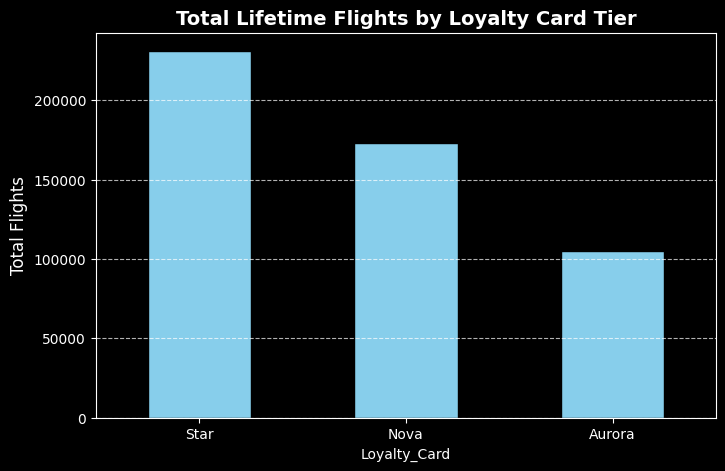

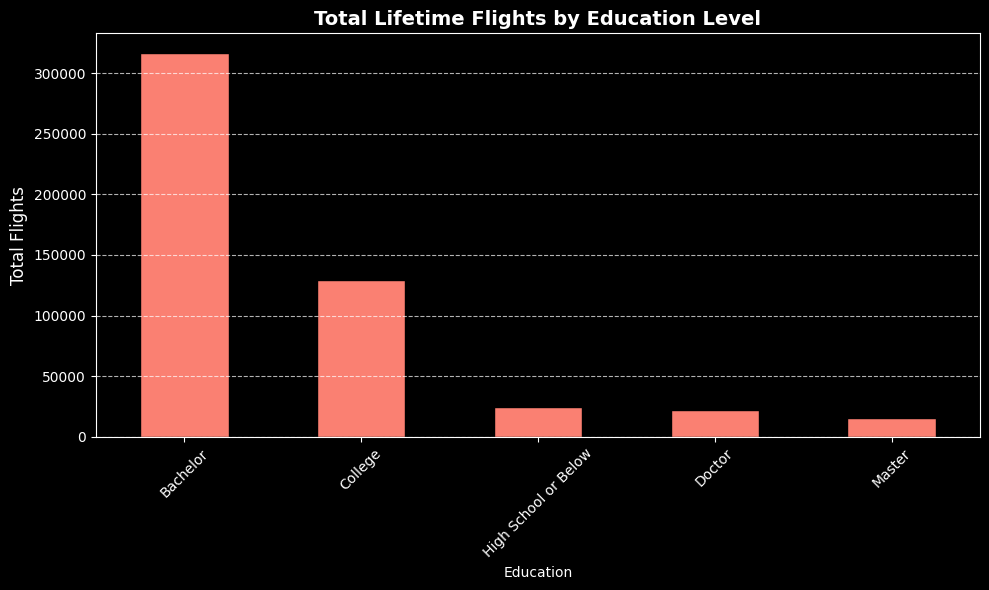

In [24]:
import matplotlib.pyplot as plt

# 1. Prepare the Data
tier_revenue = df_combined.groupby('Loyalty_Card')['Lifetime_Flights'].sum().sort_values(ascending=False)
edu_revenue = df_combined.groupby('Education')['Lifetime_Flights'].sum().sort_values(ascending=False)

# 2. Plot: Loyalty Card Tier Impact
plt.figure(figsize=(8, 5))
tier_revenue.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Total Lifetime Flights by Loyalty Card Tier', fontsize=14, fontweight='bold')
plt.ylabel('Total Flights', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3. Plot: Education Level Impact
plt.figure(figsize=(10, 6))
edu_revenue.plot(kind='bar', color='salmon', edgecolor='black')
plt.title('Total Lifetime Flights by Education Level', fontsize=14, fontweight='bold')
plt.ylabel('Total Flights', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Alright this marks the end of my notebook hope you enjoyed looking through it whether laughing at mistakes or just being interested in what youre looking at. Have a nice day or night wherever youre reading this from. :P